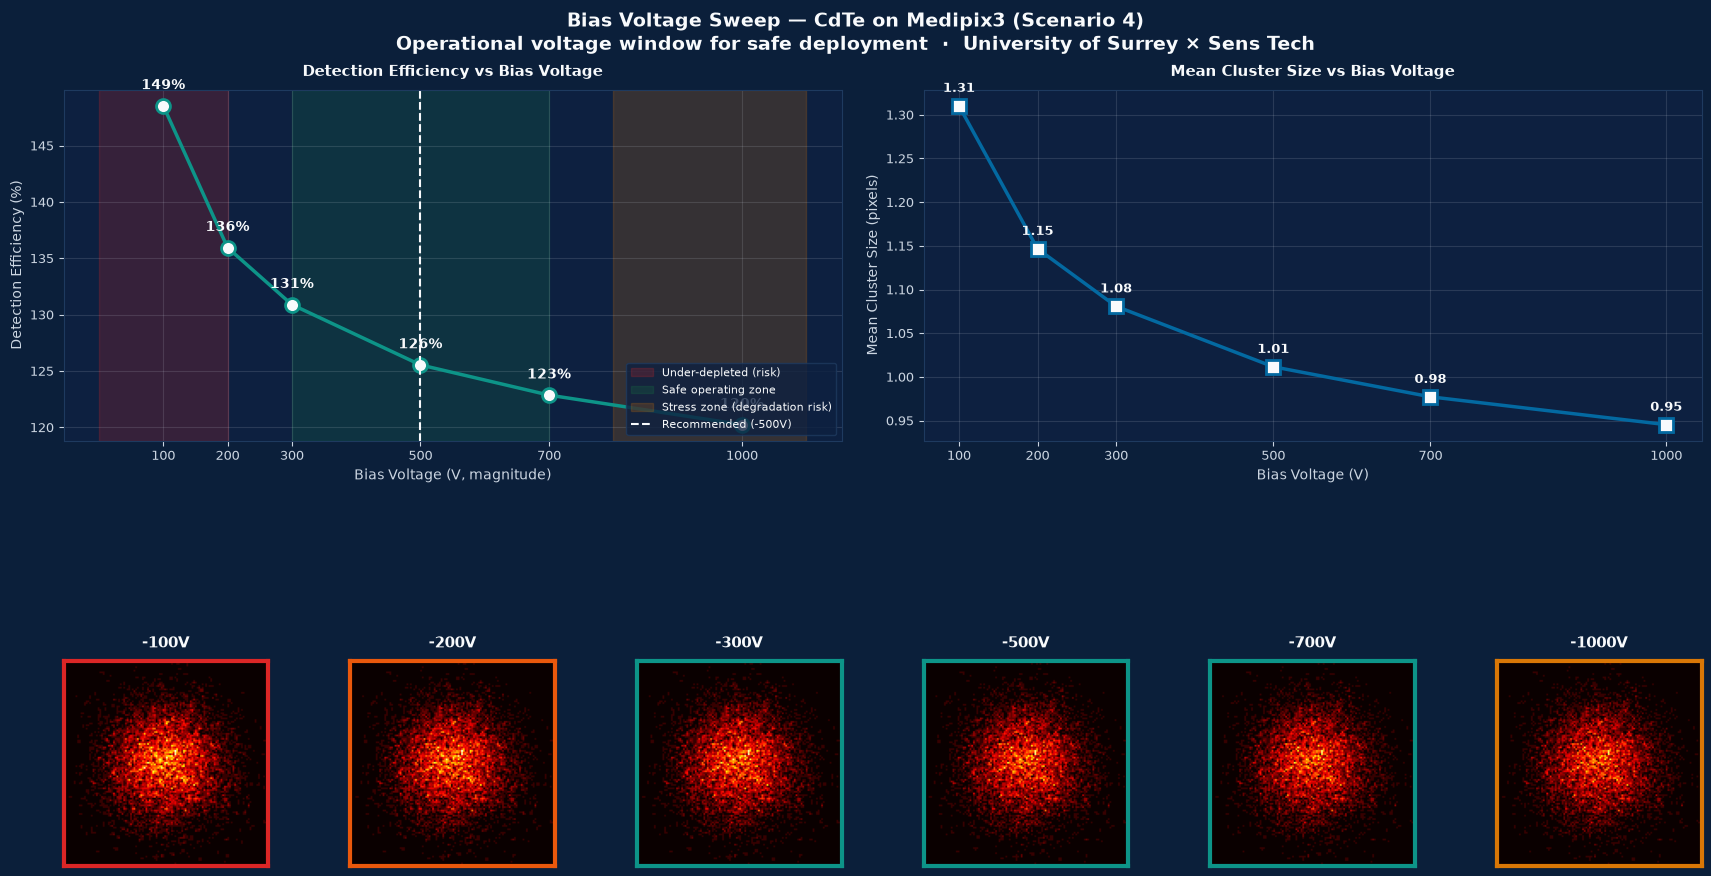

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/s4_bias_dashboard.png

── Summary ───────────────────────────────────
  - 100V → 14,854 hits | 148.5% | cluster 1.31
  - 200V → 13,595 hits | 135.9% | cluster 1.15
  - 300V → 13,089 hits | 130.9% | cluster 1.08
  - 500V → 12,554 hits | 125.5% | cluster 1.01
  - 700V → 12,286 hits | 122.9% | cluster 0.98
  -1000V → 12,024 hits | 120.2% | cluster 0.95


In [1]:
"""
Scenario 4 — Bias Voltage Sensitivity Dashboard
Operational voltage window for safe deployment.
"""

import os
os.environ["QT_QPA_PLATFORM"] = "xcb"

import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BASE = os.path.expanduser("~/itek/senstech-simulation/data")
DET = "medipix3_detector"

voltages = [100, 200, 300, 500, 700, 1000]
n_events = 10000

results = []
hit_maps = []

for V in voltages:
    path = os.path.join(BASE, f"s4_cdte_bias{V}V.root")
    f = uproot.open(path)
    pc = f[f"DetectorHistogrammer/{DET}/charge/pixel_charge;1"].to_numpy()
    hm = f[f"DetectorHistogrammer/{DET}/hit_map;1"].to_numpy()
    cs = f[f"DetectorHistogrammer/{DET}/cluster_size/cluster_size;1"].to_numpy()

    hits = int(pc[0].sum())
    mean_q = np.average(pc[1][:-1], weights=pc[0] + 1e-9)
    mean_cs = np.average(cs[1][:-1], weights=cs[0] + 1e-9)

    results.append({"voltage": V, "hits": hits,
                    "efficiency": (hits / n_events) * 100,
                    "mean_charge": mean_q, "mean_cluster": mean_cs})
    hit_maps.append(hm[0])

NAVY, WHITE, LGRAY = "#0B1F3A", "#F8FAFC", "#CBD5E1"
TEAL, BLUE, AMBER, RED = "#0D9488", "#0369A1", "#D97706", "#DC2626"

def style_ax(ax, title):
    ax.set_facecolor("#0D2040")
    ax.tick_params(colors=LGRAY, labelsize=9)
    ax.xaxis.label.set_color(LGRAY); ax.yaxis.label.set_color(LGRAY)
    ax.title.set_color(WHITE)
    ax.set_title(title, fontweight="bold", fontsize=11, pad=10)
    for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")
    ax.grid(True, alpha=0.15, color=LGRAY)

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor(NAVY)
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.55, wspace=0.4,
                       left=0.06, right=0.97, top=0.9, bottom=0.08,
                       height_ratios=[1.2, 1])

ax1 = fig.add_subplot(gs[0, :3])
style_ax(ax1, "Detection Efficiency vs Bias Voltage")
effs = [r["efficiency"] for r in results]
ax1.plot(voltages, effs, color=TEAL, linewidth=2.5, marker="o", markersize=10,
         markerfacecolor=WHITE, markeredgewidth=2)
# Operating zones
ax1.axvspan(0, 200, alpha=0.2, color=RED, label="Under-depleted (risk)")
ax1.axvspan(300, 700, alpha=0.15, color="#16A34A", label="Safe operating zone")
ax1.axvspan(800, 1100, alpha=0.2, color=AMBER, label="Stress zone (degradation risk)")
ax1.axvline(x=500, color=WHITE, linestyle="--", linewidth=1.5,
            label="Recommended (-500V)")
for r in results:
    ax1.annotate(f"{r['efficiency']:.0f}%", xy=(r["voltage"], r["efficiency"]),
                 xytext=(0, 12), textcoords="offset points", ha="center",
                 color=WHITE, fontsize=10, fontweight="bold")
ax1.set_xlabel("Bias Voltage (V, magnitude)")
ax1.set_ylabel("Detection Efficiency (%)")
ax1.set_xticks(voltages)
ax1.legend(loc="lower right", fontsize=8, labelcolor=WHITE,
           facecolor="#0D2040", edgecolor="#1E3A5F")

ax2 = fig.add_subplot(gs[0, 3:])
style_ax(ax2, "Mean Cluster Size vs Bias Voltage")
cs_vals = [r["mean_cluster"] for r in results]
ax2.plot(voltages, cs_vals, color=BLUE, linewidth=2.5, marker="s", markersize=10,
         markerfacecolor=WHITE, markeredgewidth=2)
for r in results:
    ax2.annotate(f"{r['mean_cluster']:.2f}", xy=(r["voltage"], r["mean_cluster"]),
                 xytext=(0, 10), textcoords="offset points", ha="center",
                 color=WHITE, fontsize=9, fontweight="bold")
ax2.set_xlabel("Bias Voltage (V)")
ax2.set_ylabel("Mean Cluster Size (pixels)")
ax2.set_xticks(voltages)

colors = ["#DC2626", "#EA580C", "#0D9488", "#0D9488", "#0D9488", "#D97706"]
for i, V in enumerate(voltages):
    ax = fig.add_subplot(gs[1, i])
    style_ax(ax, f"-{V}V")
    hm = hit_maps[i]
    c = hm.shape[0] // 2; cr = 60
    ax.imshow(hm[c-cr:c+cr, c-cr:c+cr], cmap="hot", origin="lower",
              aspect="equal", vmax=max(h.max() for h in hit_maps))
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor(colors[i]); s.set_linewidth(3)

fig.suptitle("Bias Voltage Sweep — CdTe on Medipix3 (Scenario 4)\n"
             "Operational voltage window for safe deployment  ·  University of Surrey × Sens Tech",
             fontsize=14, fontweight="bold", color=WHITE, y=0.98)

out = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks/s4_bias_dashboard.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

print("\n── Summary ───────────────────────────────────")
for r in results:
    print(f"  -{r['voltage']:>4}V → {r['hits']:>6,} hits | {r['efficiency']:>5.1f}% | "
          f"cluster {r['mean_cluster']:.2f}")